# Filtering TM/TR CDF plot (tvkern 0615 dsub)

Reads one selected shuffle from three 20260616 tvkern dsub reruns. Old 20260615 paths are kept below as audit comments because they include the KP920B cgt dependency bug and earlier logging/NSPV issues.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260616"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
DEFAULT_SHUFFLE_SELECT = "shuffle2"
HOST_SHUFFLE_SELECTS = {
    # Default: every host uses DEFAULT_SHUFFLE_SELECT.
    # Override one host manually, for example:
    # "c920bn3": "shuffle2",
}
SHUFFLE_SELECT = DEFAULT_SHUFFLE_SELECT
TR_MARKER_MAX = 100

# Previous 20260615 roots, kept for audit and intentionally not used:
# - 20260615-141629-tvkern-dsub: older dsub path; no script-level run start/end timestamp and command, older NSPV handling, KP wtime/papix6 risk.
# - 20260615-193641/214141/214143-tvkern-dsub-logfix: improved logging, but KP920B cgt regression: dsub/sub work was wrapped into a return-value helper and attached to sink.
# /astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/output_tvkern_filt_dsub/20260615-193641-tvkern-dsub-logfix/shuffle0
# /astrum/home/hpchzy/code/data/20260615/camd9554n1/output_tvkern_filt_dsub/20260615-214141-tvkern-dsub-logfix/shuffle0
# /astrum/home/hpchzy/code/data/20260615/c920bn3/output_tvkern_filt_dsub/20260615-214143-tvkern-dsub-logfix/shuffle0

# Previous 20260616 07:xx inline roots, kept for bug audit and intentionally not used:
# - commit: c58857265d9e6468b6d8edface53d7c75d68795c
# - data:
#   /astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-070704-tvkern-dsub-0615
#   /astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-070706-tvkern-dsub-0615
#   /astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-070709-tvkern-dsub-0615
# - bug/reason: tvkern sub_loop/dsub_loop and stencil dsub_loop were still inline-capable; this made the loop-call boundary optimizer-dependent.
#   The 09:xx noinline rerun below uses commit 80547a23841ee40feb8a805993f91da34a94fa66 to force a stable noinline boundary.

# Explicit timestamp roots for the active 09:xx noinline rerun. Do not append shuffle here;
# per-host shuffle selection is handled by HOST_SHUFFLE_SELECTS / DEFAULT_SHUFFLE_SELECT.
RUN_ROOT_OVERRIDES = {
    "cgnr6760pn2": Path("/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-082701-tvkern-dsub-noinline-0615"),
    "camd9554n1": Path("/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-082707-tvkern-dsub-noinline-0615"),
    "c920bn3": Path("/astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-082713-tvkern-dsub-noinline-0615"),
}


def shuffle_for_host(host):
    return HOST_SHUFFLE_SELECTS.get(host, DEFAULT_SHUFFLE_SELECT)


def latest_run_root(host):
    shuffle_select = shuffle_for_host(host)
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host] / shuffle_select
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/output_tvkern_filt_dsub")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / shuffle_select
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP-tvkern-dsub" / shuffle_select

RUN_ROOTS = [latest_run_root(host).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join([f"{host}-{shuffle_for_host(host)}" for host in HOST_ORDER])

QUANTILE_DROP = 0.99
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}

KERNEL_LABELS = {"tvkern": "tvkern"}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)


/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-082701-tvkern-dsub-noinline-0615/shuffle2
/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-082707-tvkern-dsub-noinline-0615/shuffle2
/astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-082713-tvkern-dsub-noinline-0615/shuffle2
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']


In [3]:
def parse_filt_dir(path):
    name = path.name
    known_timers = sorted(TIMER_LABELS, key=len, reverse=True)
    for timer in known_timers:
        patterns = [
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<ratio>[0-9.]+)_nsamp(?P<nsamp>\d+)_filt$',
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_filt$',
        ]
        for pat in patterns:
            m = re.match(pat, name)
            if m:
                d = m.groupdict()
                d['timer'] = timer
                d['np'] = int(d['np'])
                d['size'] = int(d['size'])
                d['ratio'] = float(d.get('ratio') or np.nan)
                d['nsamp'] = int(d.get('nsamp') or 0)
                return d
    return None


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    return df['ns'].dropna().to_numpy()


def read_tm_plinear(tm_file, n_bins=300):
    """Read TM samples and return piecewise-linear CDF via histogram binning.

    Same format as read_tr: ns = bin left edges (+ sentinel right edge),
    cdf = CDF at each left edge (0 at first, 1.0 at sentinel).
    """
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    vals = pd.to_numeric(df['ns'], errors='coerce').dropna().to_numpy()
    if vals.size == 0:
        return pd.DataFrame({'ns': [], 'cdf': []})
    counts, edges = np.histogram(vals, bins=min(n_bins, int(np.ptp(vals)) or n_bins))
    prob = counts / counts.sum()
    cs = np.cumsum(prob)
    left_cdf = np.r_[0.0, cs[:-1]]
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        last = int(np.where(keep)[0][-1])
        if last + 1 < len(counts):
            keep[last + 1] = True
    kept_left = edges[:-1][keep]
    kept_prob = prob[keep]
    sentinel = edges[1:][keep][-1]
    x = np.r_[kept_left, sentinel]
    y = np.r_[0.0, np.cumsum(kept_prob)]
    return pd.DataFrame({'ns': x, 'cdf': y})


def read_hist(hist_file):
    """Read tr_hist.csv / tm_hist.csv as step-function CDF.

    Format: each row is (left_edge, prob) where prob is the probability mass
    for the bin [left_edge, next_left_edge). The last row has prob=0 and
    serves as the right boundary sentinel.

    Returns a DataFrame with columns [ns, prob, cdf] suitable for step-plot:
      - ns is the LEFT edge of each bin (where the CDF step occurs)
      - cdf is the cumulative probability AFTER adding this bin's mass
      - A leading row with cdf=0 is prepended so the step starts visibly
      - The sentinel right-boundary row is kept so the last horizontal
        segment extends to the correct right edge.
    """
    df = pd.read_csv(hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    # Normalize by sum of non-sentinel prob (sentinel pr=0 contributes 0)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # Piecewise-linear CDF: cdf[i] = cumulative probability at LEFT edge of bin i
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        tm_hist_file = filt_dir / 'tm_hist.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tm_hist_file': tm_hist_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)


entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
print(f'entries: {len(entries)}')

entries = entries[(entries['timer'] != 'cntvct') & (entries['timer'] != 'tsc_native')]
entries.head(20)


entries: 396


,kernel,np,size,ratio,nsamp,timer,host,data_folder,shuffle,filt_dir,tm_file,tm_hist_file,tr_hist_file
264,tvkern,64,0,0.5,10222,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
308,tvkern,64,0,0.5,10222,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
330,tvkern,64,0,0.5,10411,papi,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
352,tvkern,64,0,0.5,10440,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
374,tvkern,64,0,0.5,10223,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
265,tvkern,64,0,0.8,10223,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
309,tvkern,64,0,0.8,10222,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
331,tvkern,64,0,0.8,10425,papi,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
353,tvkern,64,0,0.8,10454,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
375,tvkern,64,0,0.8,10237,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...


# ER/EP/Wasserstein summary


In [4]:
def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def wd_to_min(hist_file):
    df = read_hist(hist_file)
    if df.empty:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['prob'].to_numpy(dtype=float)
    if pr.sum() <= 0:
        return np.nan
    return np.sum(np.abs(ns - ns.min()) * pr) / pr.sum()


summary_rows = []
for _, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    summary_rows.append({
        **row.to_dict(),
        'ep': read_float_file(filt_folder / 'ep.out'),
        'er': read_float_file(filt_folder / 'er.out'),
        'wd': read_float_file(filt_folder / 'wd.out'),
        'tm_wd_to_min': wd_to_min(filt_folder / 'tm_hist.csv'),
        'tr_wd_to_min': wd_to_min(filt_folder / 'tr_hist.csv'),
    })

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df['timer_label'] = df['timer'].map(TIMER_LABELS).fillna(df['timer'])
df['kernel_label'] = df['kernel'].map(KERNEL_LABELS).fillna(df['kernel'])
df.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ratio', 'nsamp', 'ep', 'er', 'wd', 'tm_wd_to_min', 'tr_wd_to_min']].head(20)


,host,kernel,timer,np,size,ratio,nsamp,ep,er,wd,tm_wd_to_min,tr_wd_to_min
0,c920bn3,tvkern,cgt,64,0,0.5,10222,0.015688,0.000751,5.290452,26.663277,26.663253
1,c920bn3,tvkern,cntvcto,64,0,0.5,10222,0.002748,0.000543,3.827136,25.569801,25.569814
2,c920bn3,tvkern,papi,64,0,0.5,10411,0.001366,0.000724,5.194975,36.985522,36.985540
3,c920bn3,tvkern,papix6,64,0,0.5,10440,0.000000,0.002007,14.446231,53.076038,42.508440
4,c920bn3,tvkern,wtime,64,0,0.5,10223,0.037830,0.001709,12.050251,114.387406,114.387440
5,c920bn3,tvkern,cgt,64,0,0.8,10223,0.015688,0.000761,5.365829,26.663277,26.663253
6,c920bn3,tvkern,cntvcto,64,0,0.8,10222,0.002748,0.000736,5.182915,25.569801,25.569814
7,c920bn3,tvkern,papi,64,0,0.8,10425,0.001366,0.000702,5.040201,36.985522,36.985540
8,c920bn3,tvkern,papix6,64,0,0.8,10454,0.026273,0.001834,13.198995,53.076038,44.583910
9,c920bn3,tvkern,wtime,64,0,0.8,10237,0.037830,0.001893,13.346734,114.387406,114.387440


/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_summary_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_ratio0.5.png


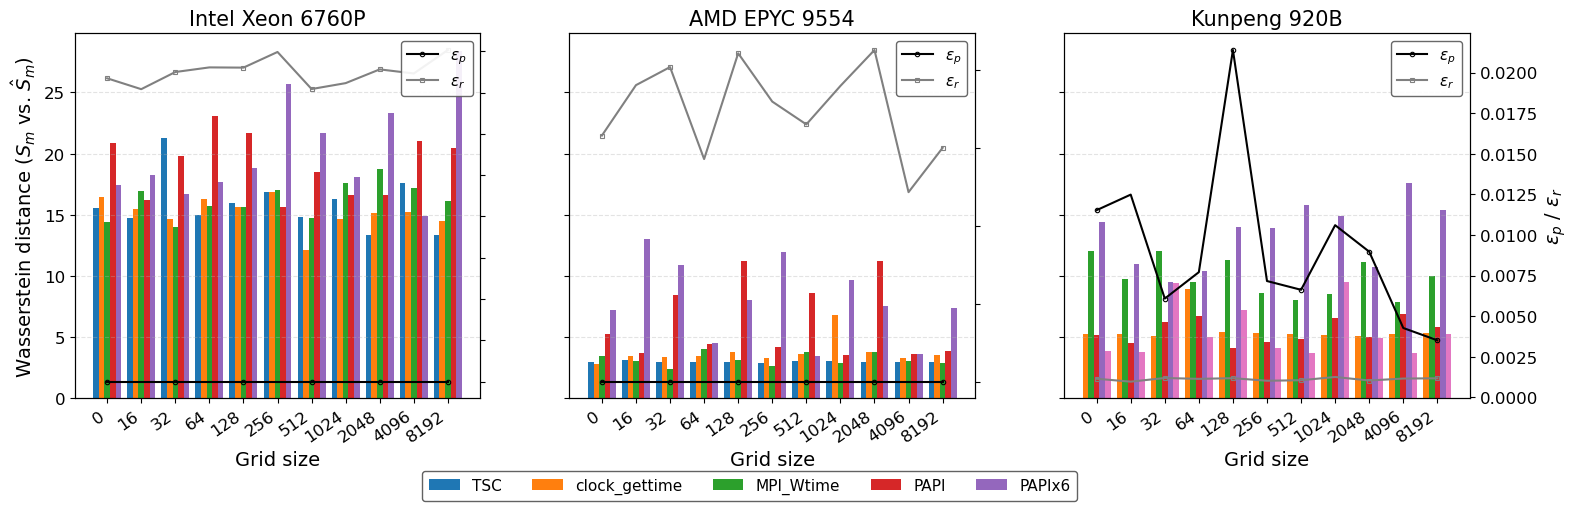

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_summary_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_ratio0.8.png


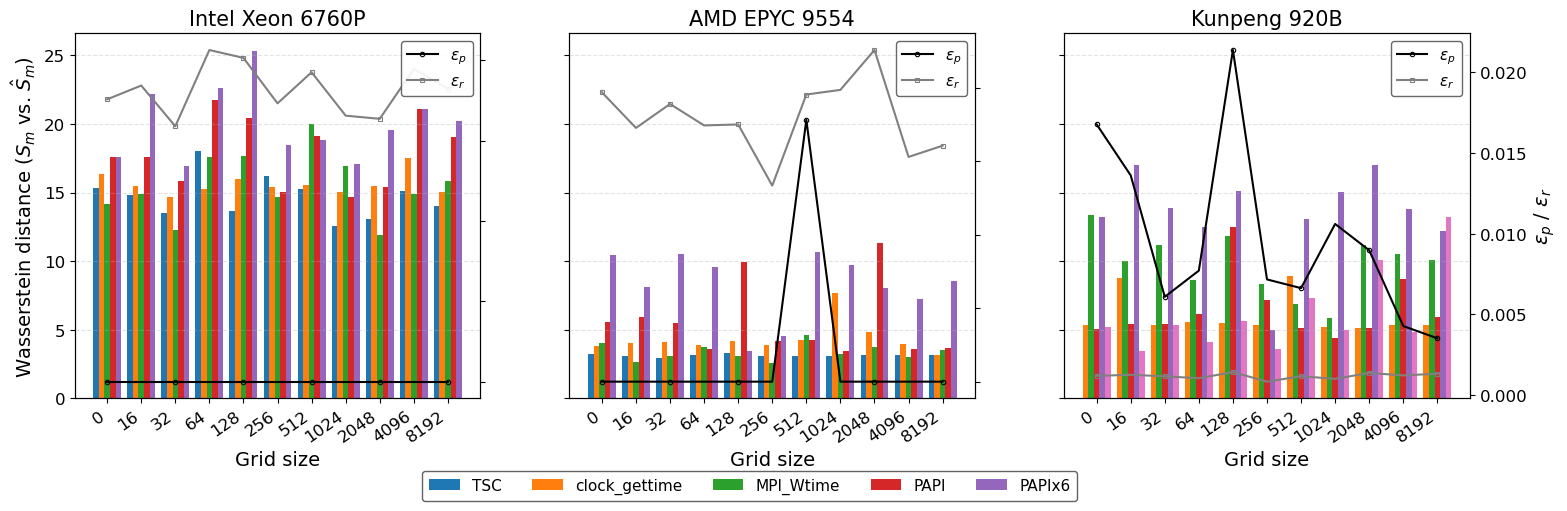

In [5]:
metric_bar = 'wd'
line_metrics = ['ep', 'er']

AXIS_LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 15
LEGEND_FONTSIZE = 11

for ratio, ratio_df in df.groupby('ratio', sort=True):
    plot_df = ratio_df.copy()
    plot_df['size_str'] = plot_df['size'].astype(str)
    size_order = [str(x) for x in sorted(plot_df['size'].unique())]
    plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

    hosts = [host for host in HOST_ORDER if host in set(plot_df['host'])]
    if not hosts:
        continue
    fig, axes = plt.subplots(1, len(hosts), figsize=(6.0 * len(hosts), 4.8), sharey=True, constrained_layout=False)
    axes = np.atleast_1d(axes)

    for ax1, host in zip(axes, hosts):
        host_df = plot_df[plot_df['host'] == host].copy()
        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)

        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            ax1.bar(x + offset, sub[metric_bar], width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))

        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid size', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.set_xticks(x)
        ax1.set_xticklabels(size_order, rotation=35, ha='right', fontsize=TICK_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.35)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        if ax1 is axes[0]:
            ax1.set_ylabel(r'Wasserstein distance ($S_m$ vs. $\hat{S}_m$)', fontsize=AXIS_LABEL_FONTSIZE)

        ax2 = ax1.twinx()
        line_df = host_df.groupby('size_str', observed=True)[line_metrics].mean().reindex(size_order)
        ep_line, = ax2.plot(x, line_df['ep'], marker='o', markevery=2, markersize=3.2, markerfacecolor='none', markeredgewidth=0.8, label=r'$\epsilon_p$', color='black')
        er_line, = ax2.plot(x, line_df['er'], marker='s', markevery=2, markersize=3.2, markerfacecolor='none', markeredgewidth=0.8, label=r'$\epsilon_r$', color='gray')
        # ax2.set_ylim(0, 0.05)
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        if ax1 is axes[-1]:
            ax2.set_ylabel(r'$\epsilon_p$ / $\epsilon_r$', fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax2.set_yticklabels([])
        ax2.legend(handles=[ep_line, er_line], loc='upper right', fontsize=LEGEND_FONTSIZE, frameon=True, framealpha=0.9, edgecolor='0.35')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        ncol=min(6, max(1, len(labels))), fontsize=LEGEND_FONTSIZE,
        loc='lower center', bbox_to_anchor=(0.5, -0.13),
        frameon=True, framealpha=0.95, edgecolor='0.35', borderpad=0.45,
    )
    # fig.suptitle(f'tvkern dsub, {SHUFFLE_LABEL}, nsampRatio={ratio:g}', y=1.02)
    # fig.suptitle(f'Wasserstein ', y=1.02)
    fig.subplots_adjust(bottom=0.10, top=0.86, wspace=0.22)

    if SAVE_FIG:
        out = OUT_DIR / f'tvkern_dsub_summary_{SHUFFLE_LABEL}_ratio{ratio:g}.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)
    plt.show()


# TM/TR CDF plots


/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size0_ratio0.5_tm_tr_mark.png


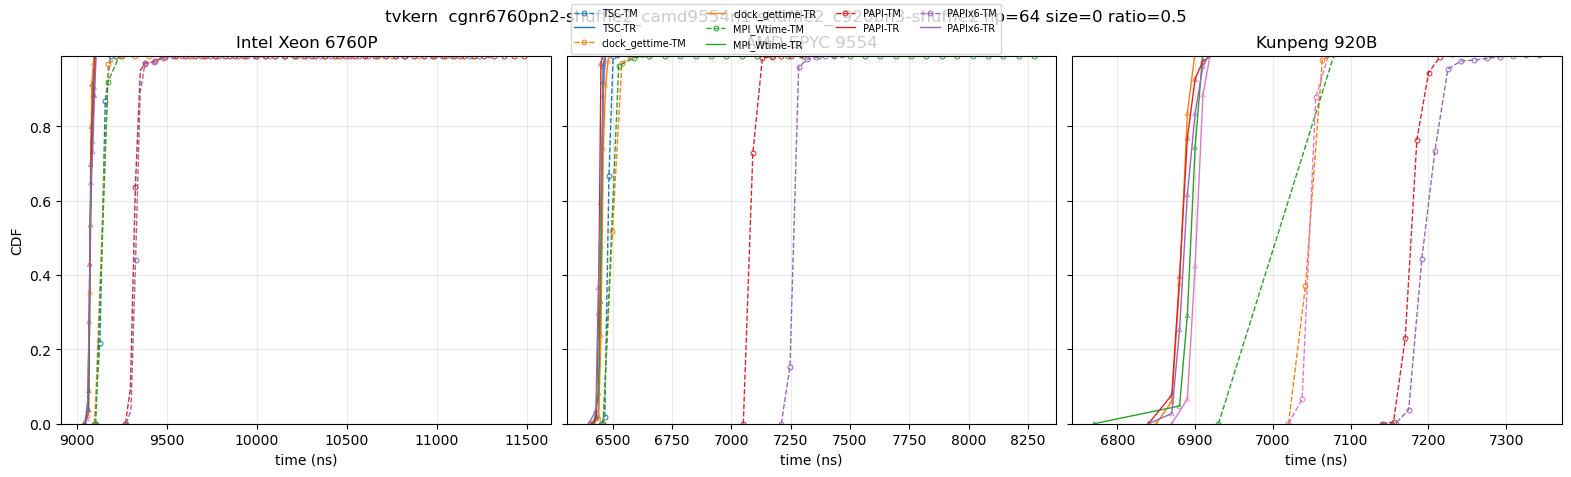

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_mark.png


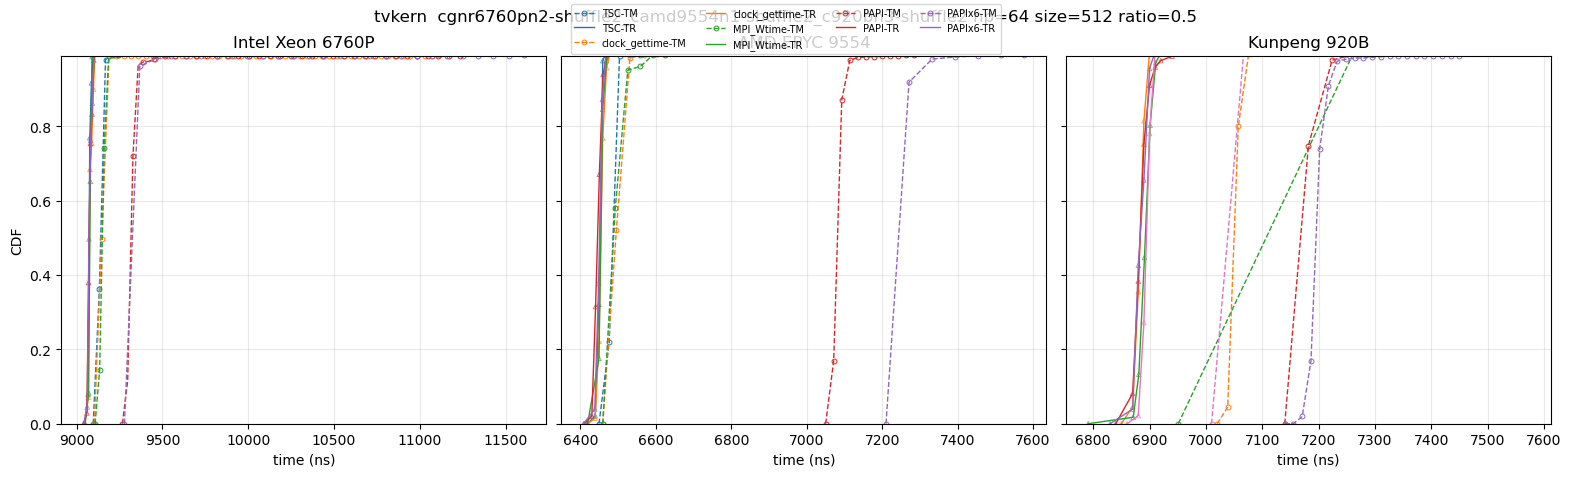

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_mark.png


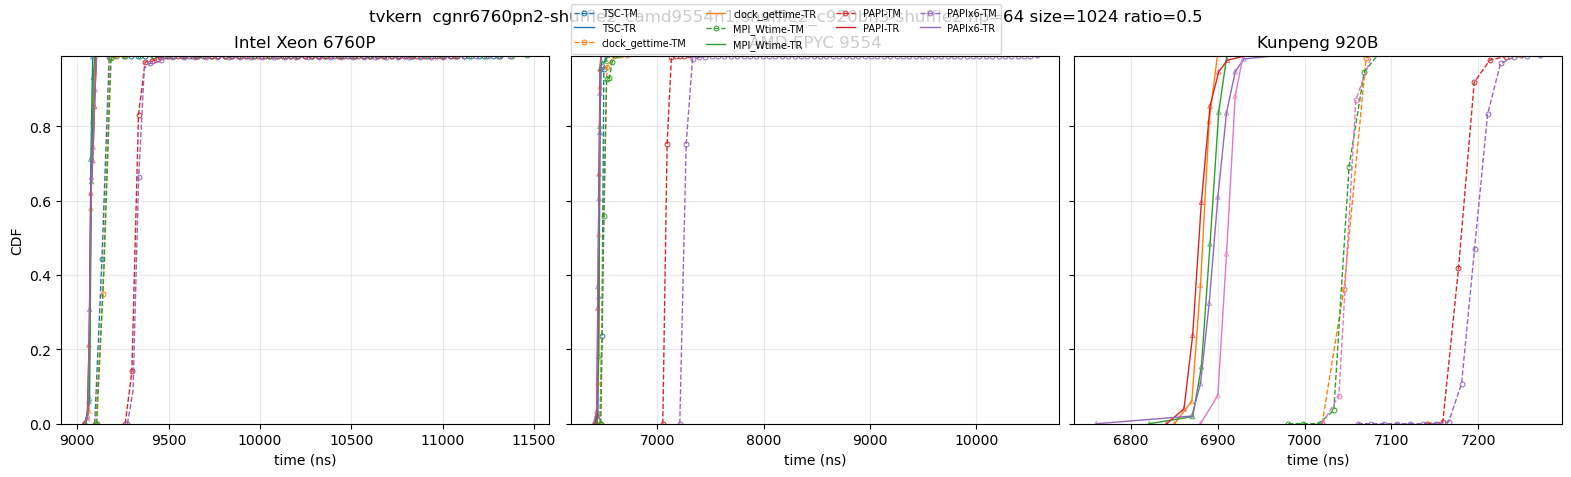

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_mark.png


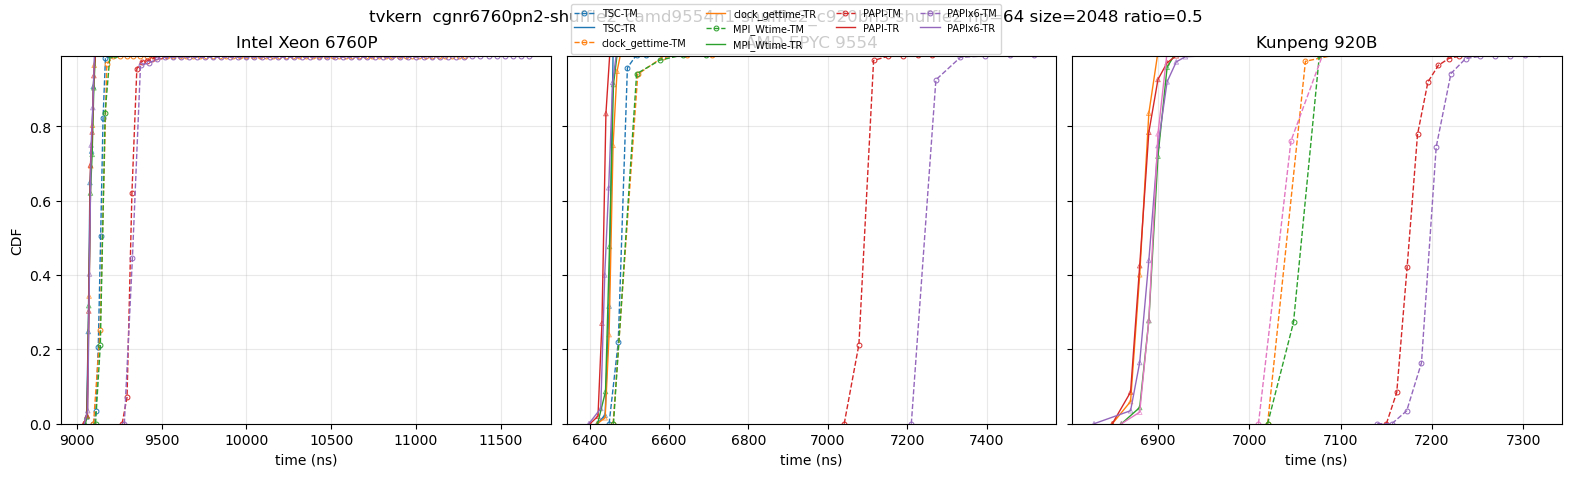

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size4096_ratio0.5_tm_tr_mark.png


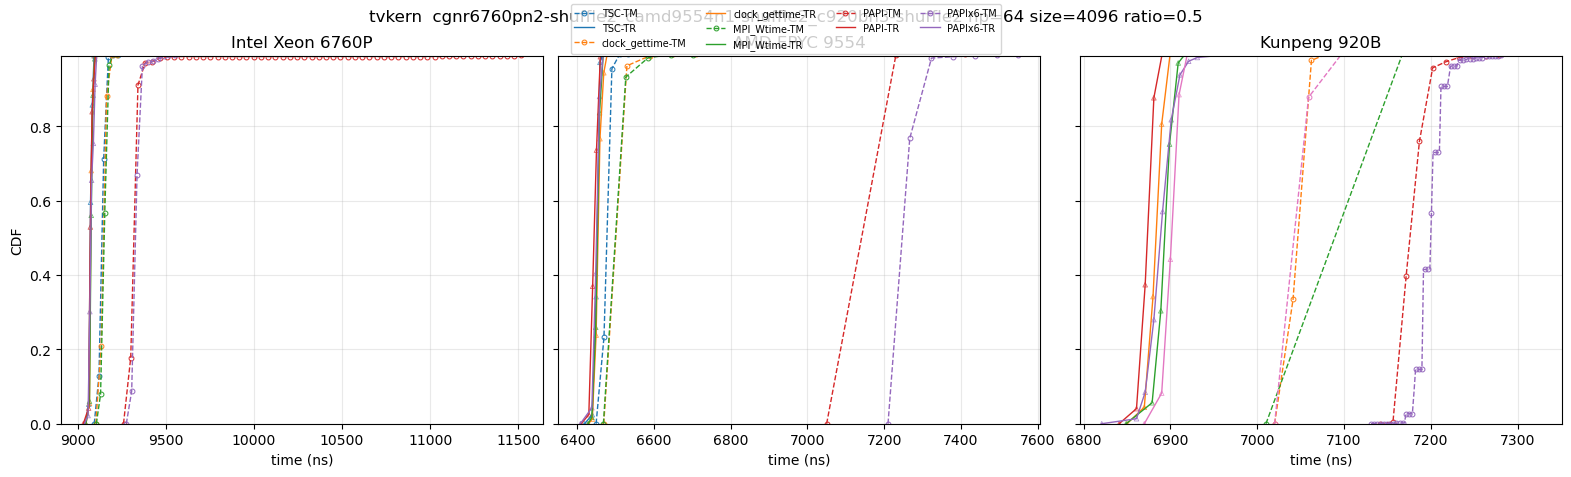

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size8192_ratio0.5_tm_tr_mark.png


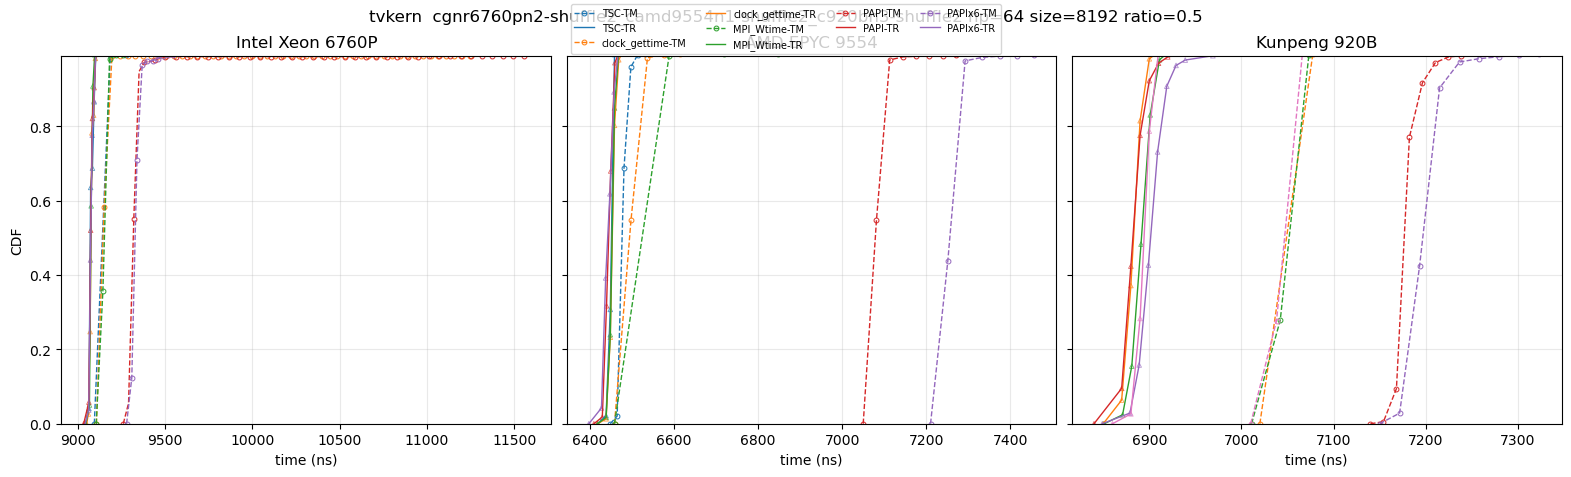

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size0_ratio0.8_tm_tr_mark.png


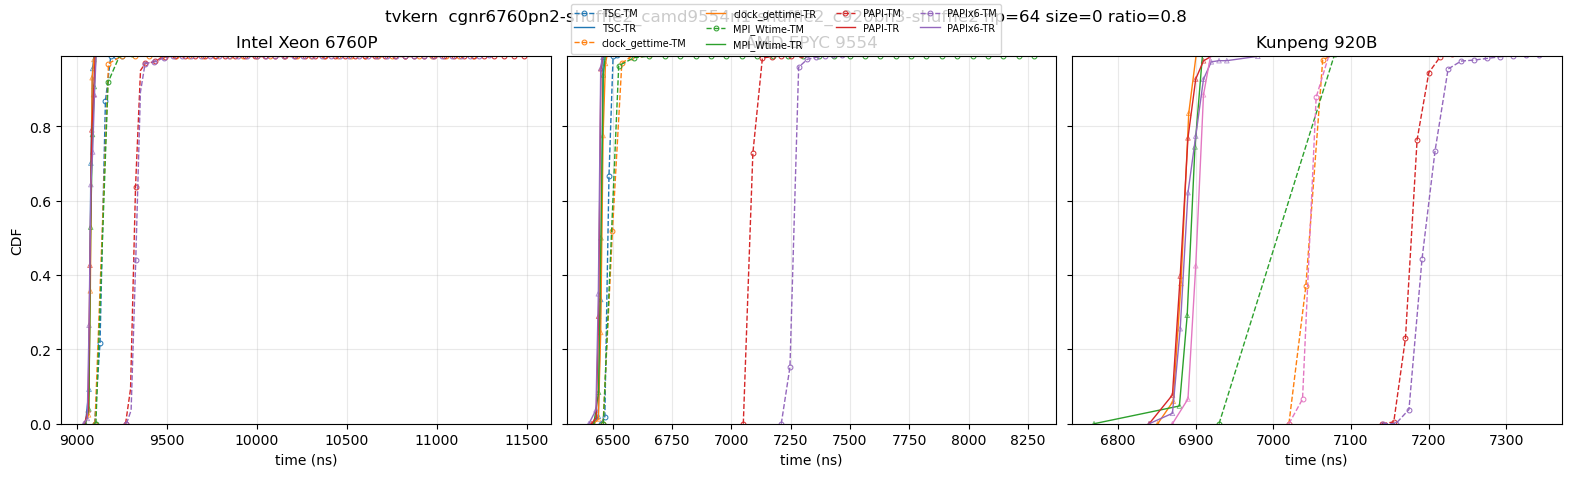

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.8_tm_tr_mark.png


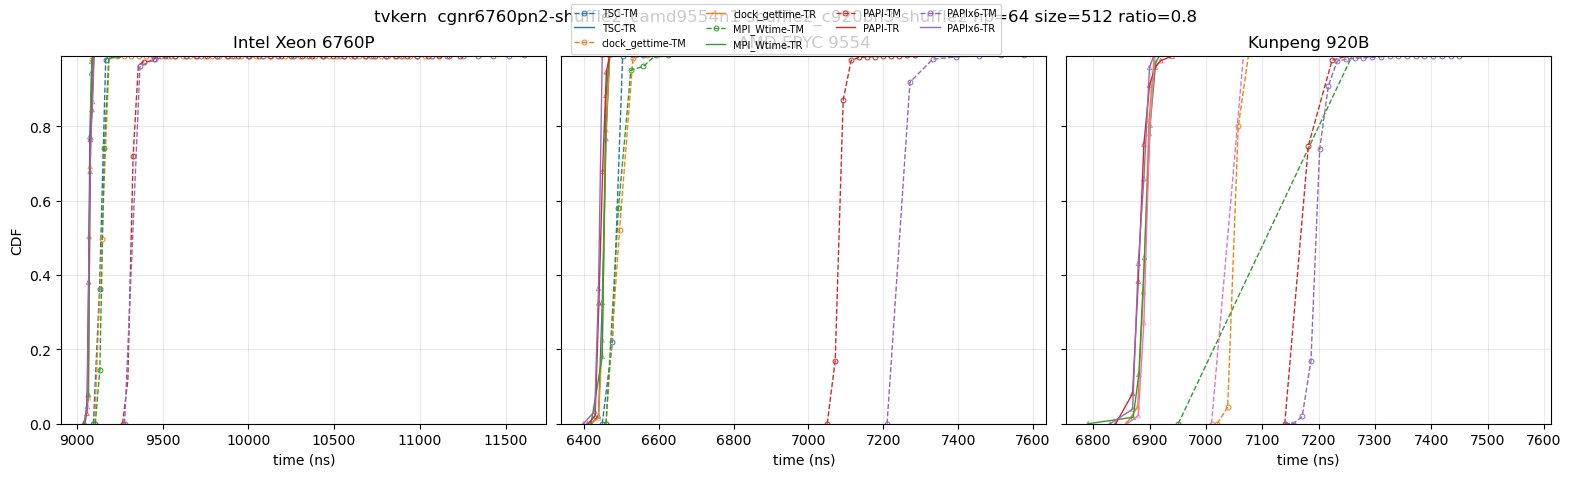

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.8_tm_tr_mark.png


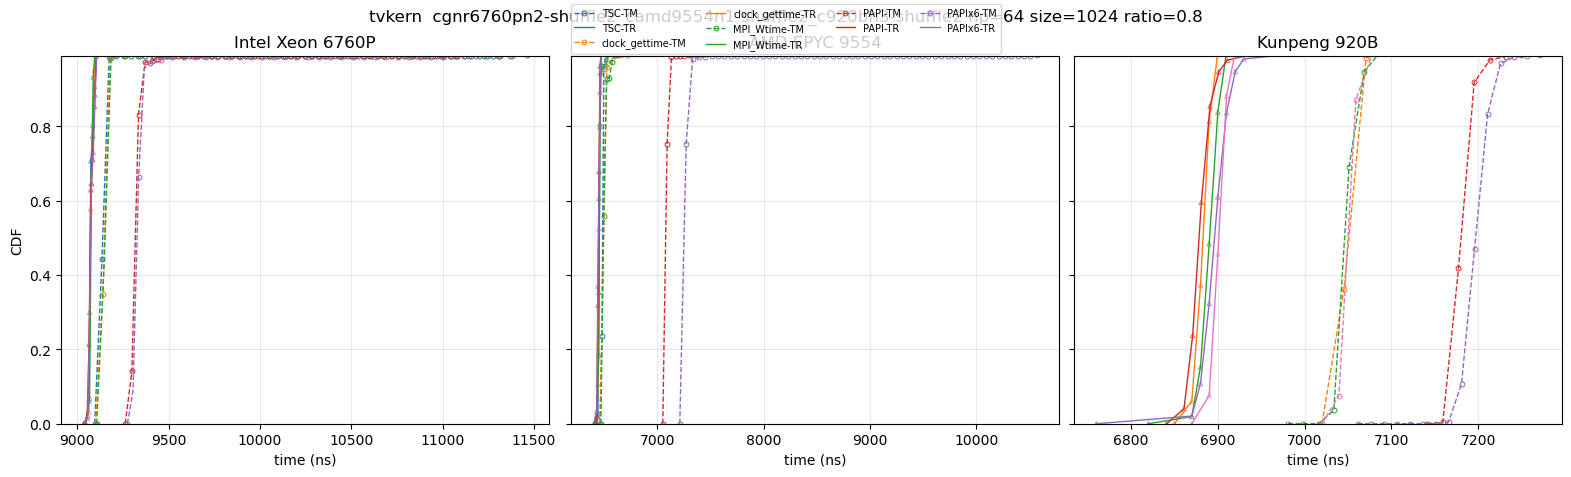

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.8_tm_tr_mark.png


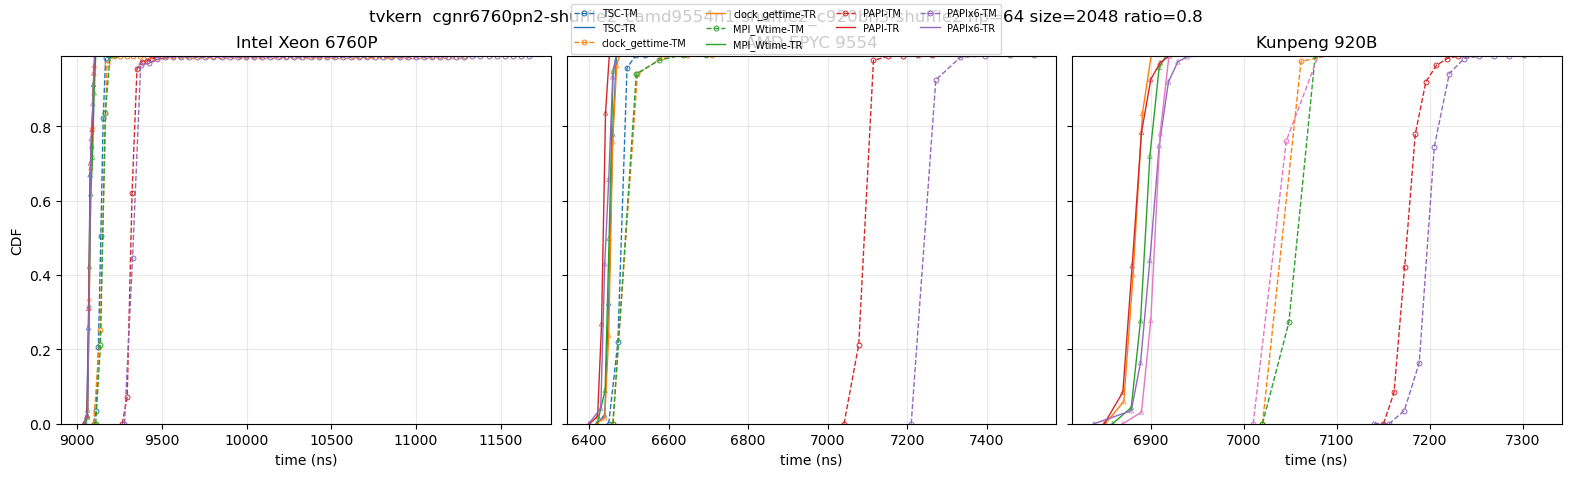

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size4096_ratio0.8_tm_tr_mark.png


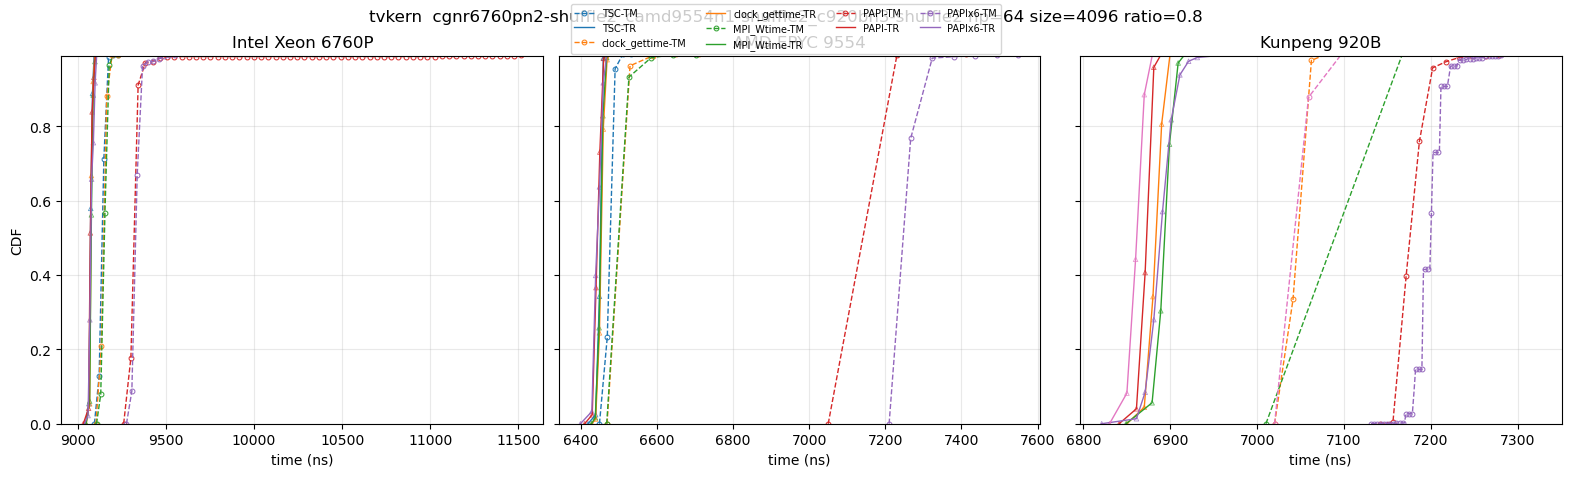

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size8192_ratio0.8_tm_tr_mark.png


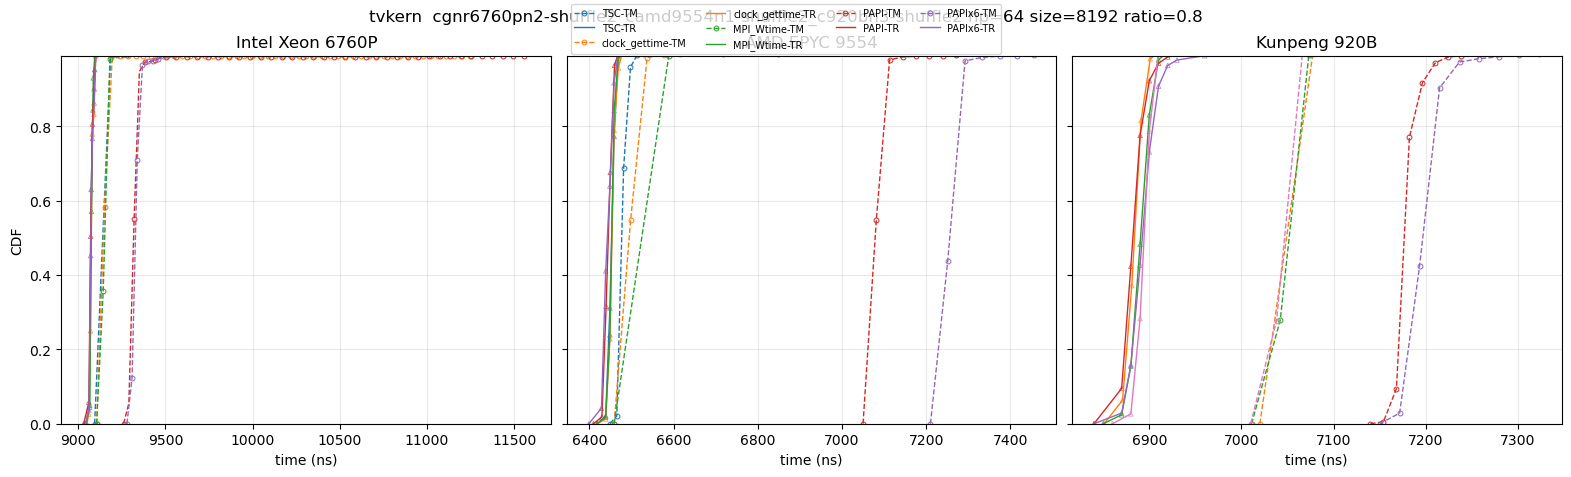

In [6]:
PLOT_SIZES = [0, 512, 1024, 2048, 4096, 8192]

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

for ratio in sorted(entries['ratio'].dropna().unique()):
    for size in PLOT_SIZES:
        entries_plot = entries[(entries['ratio'] == ratio) & (entries['size'] == size)]
        if entries_plot.empty:
            continue

        for (kernel, np_val), group_all in entries_plot.groupby(['kernel', 'np'], sort=True):
            hosts = [host for host in HOST_ORDER if host in set(group_all['host'])]
            if not hosts:
                continue
            fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4.4), sharey=True, constrained_layout=True)
            axes = np.atleast_1d(axes)

            for ax, host in zip(axes, hosts):
                group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))
                for _, row in group.iterrows():
                    timer = row['timer']
                    color = TIMER_COLORS.get(timer)
                    label = timer_label(timer)

                    tm_df = read_tm_plinear(row['tm_file'])
                    tr_df = read_hist(row['tr_hist_file'])

                    tm_ns = tm_df['ns'].to_numpy()
                    tm_cdf = tm_df['cdf'].to_numpy()
                    tm_markevery = max(1, len(tm_ns) // 30)

                    tr_ns = tr_df['ns'].to_numpy()
                    tr_cdf = tr_df['cdf'].to_numpy()
                    if len(tr_ns) > TR_MARKER_MAX:
                        keep = np.linspace(0, len(tr_ns) - 1, TR_MARKER_MAX, dtype=int)
                        tr_marker_x = tr_ns[keep]
                        tr_marker_y = tr_cdf[keep]
                    else:
                        tr_marker_x = tr_ns
                        tr_marker_y = tr_cdf

                    ax.plot(tm_ns, tm_cdf, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_markevery, markersize=7, markerfacecolor='none', markeredgewidth=0.7)
                    ax.plot(tr_ns, tr_cdf, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0)
                    ax.scatter(tr_marker_x, tr_marker_y, color=color, marker='^', s=11, linewidths=0.6, facecolor='none', alpha=0.72)

                ax.set_title(HOST_LABELS.get(host, host))
                ax.set_xlabel('time (ns)')
                ax.set_ylim(0, QUANTILE_DROP)
                ax.grid(True, alpha=0.28)
                if ax is axes[0]:
                    ax.set_ylabel('CDF')

            handles, labels = axes[0].get_legend_handles_labels()
            fig.legend(handles, labels, ncol=min(4, max(1, len(labels))), fontsize=7, loc='upper center')
            fig.suptitle(f'{KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL} np={np_val} size={size} ratio={ratio:g}', y=1.05)

            if SAVE_FIG:
                out = OUT_DIR / f'{kernel}_dsub_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{ratio:g}_tm_tr_mark.png'
                fig.savefig(out, dpi=220, bbox_inches='tight')
                print(out)
            plt.show()


In [7]:
(df.groupby(['ratio', 'size'])['timer']
   .nunique()
   .unstack('ratio')
   .fillna(0)
   .astype(int))


ratio,0.5,0.8
size,,
0,6,6
16,6,6
32,6,6
64,6,6
128,6,6
256,6,6
512,6,6
1024,6,6
2048,6,6
